<a href="https://colab.research.google.com/github/chensetkim/GEO-AI-WorkShop2026/blob/master/project1/Alv_lulc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geo-AI Workshop Project: LULC Segmentation

**Project title:** Mapping Buid-up, Cropland, road, water, Bare soi,  forest from Sentenail-2 Images using U-Net Model in the ALV district,  Cambodia

Present by: OUK HUY, Chenset Kim




In [ ]:
# Install (uncomment if needed)
# !pip install torch torchvision matplotlib numpy scikit-learn tqdm

import tensorflow as tf
from tensorflow.keras import layers, models

import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.patches as mpatches
import os
from skimage.io import imread

tf.random.set_seed(42)
np.random.seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU(s) available: {[g.name for g in gpus]}')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('No GPU found, using CPU')

print(f'TensorFlow version: {tf.__version__}')

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
!pip install imagecodecs

Section 2: Download Dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Update img_dir and mask_dir to point to the exported GeoTIFF files in Google Drive
# Make sure the export tasks ('kulenpark_image_export' and 'kulencashew_mask_export') are complete before running this.
img_dir = '/content/drive/MyDrive/GEE_Exports/Untitled folder/alv_sentinel2_lulc_2024.tif'
mask_dir = '/content/drive/MyDrive/GEE_Exports/Untitled folder/lulc_label_remap.tif'

print(f"Updated img_dir: {img_dir}")
print(f"Updated mask_dir: {mask_dir}")

Updated img_dir: /content/drive/MyDrive/GEE_Exports/Untitled folder/alv_sentinel2_lulc_2024.tif
Updated mask_dir: /content/drive/MyDrive/GEE_Exports/Untitled folder/lulc_label_remap.tif


In [ ]:
import rasterio
import numpy as np

# Sentinel image
with rasterio.open(img_dir) as src:
    print("Sentinel")
    print("Bands :", src.count)
    print("Size  :", src.width, src.height)
    print("CRS   :", src.crs)
    print("dtype :", src.dtypes)

# Label
with rasterio.open(mask_dir) as src:
    mask = src.read(1)

print("\nMask")
print(mask.shape)
print("Classes:", np.unique(mask))

Sentinel
Bands : 10
Size  : 303 255
CRS   : EPSG:32648
dtype : ('float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32')

Mask
(255, 303)
Classes: [0 1 2 3 4 5 6]


/tmp/ipykernel_1884/134109538.py:14: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  mask = src.read(1)


In [ ]:
# Correct for multi-class LULC
Y = mask.astype(np.int32)

# Add batch dimension only
Y = np.expand_dims(Y, axis=0)   # (1, H, W)

print("Y shape:", Y.shape)
print("Y classes:", np.unique(Y))

Y shape: (1, 255, 303)
Y classes: [0 1 2 3 4 5 6]


In [ ]:
import rasterio
with rasterio.open(img_dir) as src:
    img = src.read()

X = img.astype(np.float32)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
X = np.clip(X, 0, 1)

X = np.expand_dims(X, axis=0)   # (1, H, W, C)

Y = mask.astype(np.int32)
Y = np.expand_dims(Y, axis=0)   # (1, H, W)

print("X:", X.shape)
print("Y:", Y.shape)
print("Classes:", np.unique(Y))

X: (1, 10, 255, 303)
Y: (1, 255, 303)
Classes: [0 1 2 3 4 5 6]


In [ ]:
print(img.shape)

(10, 255, 303)


In [ ]:
import rasterio
import numpy as np

with rasterio.open(img_dir) as src:
    img = src.read()   # usually (bands, H, W)

print("Raw img:", img.shape)

# If rasterio gives (bands,H,W)
if img.shape[0] == 10:
    img = np.moveaxis(img, 0, -1)   # (H,W,10)

print("Fixed img:", img.shape)

with rasterio.open(mask_dir) as src:
    mask = src.read(1)

X = img.astype(np.float32)
X = np.nan_to_num(X)
X = np.clip(X, 0, 1)
X = np.expand_dims(X, axis=0)

Y = mask.astype(np.int32)
Y = np.expand_dims(Y, axis=0)

print("X:", X.shape)
print("Y:", Y.shape)
print("Classes:", np.unique(Y))

Raw img: (10, 255, 303)
Fixed img: (255, 303, 10)
X: (1, 255, 303, 10)
Y: (1, 255, 303)
Classes: [0 1 2 3 4 5 6]


/tmp/ipykernel_1884/2365314305.py:16: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  mask = src.read(1)


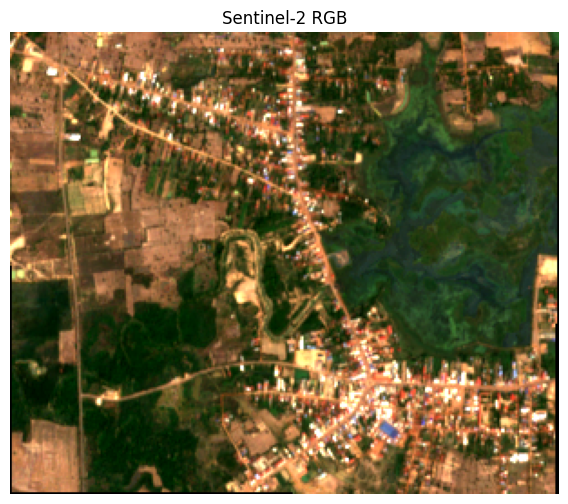

In [ ]:
rgb = X[0][:,:, [2,1,0]]

valid = rgb[rgb > 0]
low = np.percentile(valid, 2)
high = np.percentile(valid, 98)

rgb = np.clip((rgb - low) / (high - low), 0, 1)

plt.figure(figsize=(8,6))
plt.imshow(rgb)
plt.title("Sentinel-2 RGB")
plt.axis("off")
plt.show()

In [ ]:
unique, counts = np.unique(Y, return_counts=True)

print("Pixel distribution")
print("-"*30)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c:,} pixels ({100*c/Y.size:.2f}%)")

Pixel distribution
------------------------------
Class 0: 65,037 pixels (84.17%)
Class 1: 2,470 pixels (3.20%)
Class 2: 4,512 pixels (5.84%)
Class 3: 354 pixels (0.46%)
Class 4: 2,515 pixels (3.26%)
Class 5: 2,027 pixels (2.62%)
Class 6: 350 pixels (0.45%)


In [ ]:
import numpy as np

print(f'Loaded  X : {X.shape}  dtype={X.dtype}')
print(f'Loaded  Y : {Y.shape}  dtype={Y.dtype}')

# ── 1. Clean and normalize X only ───────────────────
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

if X.max() > 1.5:
    X = X / 10000.0

X = np.clip(X, 0.0, 1.0)

# Multi-class labels must stay integer
Y = Y.astype(np.int32)

print(f'X range   : [{X.min():.3f}, {X.max():.3f}]')
print(f'Y classes : {np.unique(Y)}')

n_samples = X.shape[0]
img_h, img_w, n_channels = X.shape[1], X.shape[2], X.shape[3]

print('\nAfter pre-processing:')
print(f'  X : {X.shape}  (N,H,W,C)')
print(f'  Y : {Y.shape}  (N,H,W)')
print(f'  n_channels={n_channels}   image size={img_h}x{img_w}')


# ── 2. Extract overlapping patches ──────────────────
PATCH_SIZE = 64
STRIDE = 16

def make_patches_lulc(X_arr, Y_arr, patch_size=64, stride=16):
    patches = []

    for img, lbl in zip(X_arr, Y_arr):
        h, w = lbl.shape

        for y in range(0, h - patch_size + 1, stride):
            for x in range(0, w - patch_size + 1, stride):

                img_patch = img[y:y+patch_size, x:x+patch_size, :]
                lbl_patch = lbl[y:y+patch_size, x:x+patch_size]

                patches.append((img_patch, lbl_patch))

    return patches


all_patches = make_patches_lulc(
    X, Y,
    patch_size=PATCH_SIZE,
    stride=STRIDE
)

print(f'\nTotal patches : {len(all_patches)}')
print(f'Patch image   : {all_patches[0][0].shape}')
print(f'Patch label   : {all_patches[0][1].shape}')


# ── 3. Class metadata ───────────────────────────────
N_CLASSES = 7

CLASS_NAMES = [
    'Background',
    'Built-up',
    'Cropland',
    'Road',
    'Water',
    'Forest',
    'Bare soil'
]

CLASS_COLORS = [
    '#000000',  # 0 Background
    '#E8534A',  # 1 Built-up
    '#5CA854',  # 2 Cropland
    '#F1C40F',  # 3 Road
    '#4A90D9',  # 4 Water
    '#006400',  # 5 Forest
    '#D2B48C'   # 6 Bare soil
]

print(f'\nDetected {N_CLASSES} classes -> {CLASS_NAMES}')


# ── 4. Patch class check ────────────────────────────
pixel_counts = np.zeros(N_CLASSES, dtype=np.int64)

for _, lbl in all_patches:
    vals, counts = np.unique(lbl, return_counts=True)
    for v, c in zip(vals, counts):
        if 0 <= int(v) < N_CLASSES:
            pixel_counts[int(v)] += c

print('\nPixel count in patches:')
for i in range(N_CLASSES):
    print(f'{i} {CLASS_NAMES[i]:12s}: {pixel_counts[i]:,}')


# ── 5. Keep useful patches ──────────────────────────
# Keep patches that contain at least one real LULC class
useful_patches = [
    p for p in all_patches
    if np.any(p[1] > 0)
]

print(f'\nUseful patches : {len(useful_patches)}')


# ── 6. Train / validation split ─────────────────────
rng = np.random.RandomState(42)
indices = rng.permutation(len(useful_patches))

split = int(0.8 * len(indices))

train_patches = [useful_patches[i] for i in indices[:split]]
val_patches   = [useful_patches[i] for i in indices[split:]]

print(f'\nTrain patches : {len(train_patches)}')
print(f'Val   patches : {len(val_patches)}')


# ── 7. Convert patches to arrays ────────────────────
X_train = np.array([p[0] for p in train_patches], dtype=np.float32)
Y_train = np.array([p[1] for p in train_patches], dtype=np.int32)

X_val = np.array([p[0] for p in val_patches], dtype=np.float32)
Y_val = np.array([p[1] for p in val_patches], dtype=np.int32)

print(f'\nX_train : {X_train.shape}')
print(f'Y_train : {Y_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'Y_val   : {Y_val.shape}')


# ── 8. Full scene for inference ─────────────────────
scene_img = X[0]
scene_label = Y[0]

print(f'\nScene image : {scene_img.shape}')
print(f'Scene label : {scene_label.shape}')

Loaded  X : (1, 255, 303, 10)  dtype=float32
Loaded  Y : (1, 255, 303)  dtype=int32
X range   : [0.000, 0.649]
Y classes : [0 1 2 3 4 5 6]

After pre-processing:
  X : (1, 255, 303, 10)  (N,H,W,C)
  Y : (1, 255, 303)  (N,H,W)
  n_channels=10   image size=255x303

Total patches : 180
Patch image   : (64, 64, 10)
Patch label   : (64, 64)

Detected 7 classes -> ['Background', 'Built-up', 'Cropland', 'Road', 'Water', 'Forest', 'Bare soil']

Pixel count in patches:
0 Background  : 619,766
1 Built-up    : 24,638
2 Cropland    : 30,353
3 Road        : 3,169
4 Water       : 32,284
5 Forest      : 23,483
6 Bare soil   : 3,587

Useful patches : 180

Train patches : 144
Val   patches : 36

X_train : (144, 64, 64, 10)
Y_train : (144, 64, 64)
X_val   : (36, 64, 64, 10)
Y_val   : (36, 64, 64)

Scene image : (255, 303, 10)
Scene label : (255, 303)


In [ ]:
len(all_patches)

180

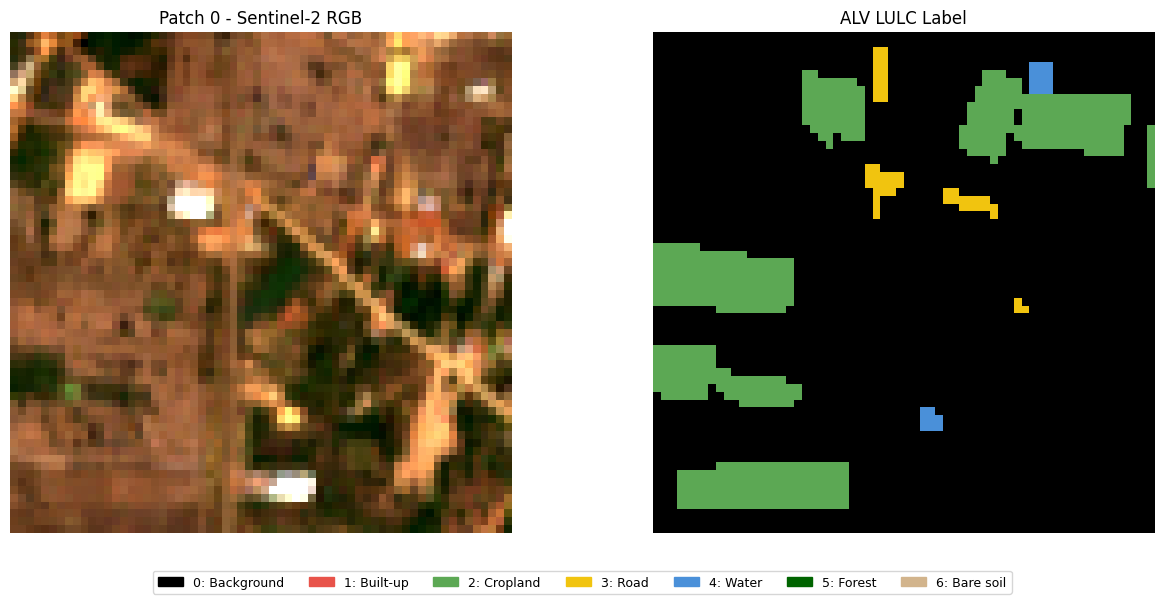

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

CLASS_NAMES = [
    "Background",  # 0
    "Built-up",    # 1
    "Cropland",    # 2
    "Road",        # 3
    "Water",       # 4
    "Forest",      # 5
    "Bare soil"    # 6
]

CLASS_COLORS = [
    "#000000",  # 0 Background
    "#E8534A",  # 1 Built-up
    "#5CA854",  # 2 Cropland
    "#F1C40F",  # 3 Road
    "#4A90D9",  # 4 Water
    "#006400",  # 5 Forest
    "#D2B48C"   # 6 Bare soil
]

cmap = ListedColormap(CLASS_COLORS)

n = 0

img = all_patches[n][0]
mask = all_patches[n][1]

rgb = img[:, :, [2, 1, 0]]

valid = rgb[rgb > 0]
if valid.size > 0:
    low = np.percentile(valid, 2)
    high = np.percentile(valid, 98)
    if high > low:
        rgb = np.clip((rgb - low) / (high - low), 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 6))

ax[0].imshow(rgb)
ax[0].set_title(f"Patch {n} - Sentinel-2 RGB")
ax[0].axis("off")

ax[1].imshow(mask, cmap=cmap, vmin=0, vmax=6)
ax[1].set_title("ALV LULC Label")
ax[1].axis("off")

legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[i], label=f"{i}: {CLASS_NAMES[i]}")
    for i in range(len(CLASS_NAMES))
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=7,
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np

# ALV LULC image has 10 Sentinel-2 bands
n_channels = X_train.shape[-1]

def augment(img, lbl):
    """
    Synchronized random flip + 90-degree rotation
    for multi-class ALV LULC segmentation.

    img: (64,64,10) or (128,128,10)
    lbl: (64,64) or (128,128)
    labels: 0–6
    """

    lbl_exp = tf.expand_dims(lbl, axis=-1)
    lbl_exp = tf.cast(lbl_exp, img.dtype)

    stacked = tf.concat([img, lbl_exp], axis=-1)

    stacked = tf.image.random_flip_left_right(stacked)
    stacked = tf.image.random_flip_up_down(stacked)

    k = tf.random.uniform((), 0, 4, dtype=tf.int32)
    stacked = tf.image.rot90(stacked, k)

    img_out = stacked[..., :n_channels]
    lbl_out = stacked[..., n_channels]

    # keep integer class IDs 0–6
    lbl_out = tf.cast(tf.round(lbl_out), tf.int32)

    return img_out, lbl_out


def make_tf_dataset(patches, batch_size=4, augment_fn=None, shuffle=True):
    imgs = np.stack([p[0] for p in patches]).astype(np.float32)
    lbls = np.stack([p[1] for p in patches]).astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((imgs, lbls))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(patches), seed=42)

    if augment_fn is not None:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


BATCH_SIZE = 4

train_ds = make_tf_dataset(
    train_patches,
    batch_size=BATCH_SIZE,
    augment_fn=augment,
    shuffle=True
)

val_ds = make_tf_dataset(
    val_patches,
    batch_size=BATCH_SIZE,
    augment_fn=None,
    shuffle=False
)

for imgs, lbls in train_ds.take(1):
    print(f"Batch images: {imgs.shape}")
    print(f"Batch labels: {lbls.shape}")
    print(f"Label classes in batch: {tf.unique(tf.reshape(lbls, [-1]))[0].numpy()}")

Batch images: (4, 64, 64, 10)
Batch labels: (4, 64, 64)
Label classes in batch: [0 1 3 6 2 4 5]


In [ ]:
from tensorflow.keras import layers, models

# ---------------------------------------------------
# Multi-class U-Net Model for ALV LULC
# ---------------------------------------------------
def unet_lulc(input_size=(PATCH_SIZE, PATCH_SIZE, n_channels), n_classes=N_CLASSES):

    inputs = layers.Input(shape=input_size)

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(512, 3, activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(512, 3, activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(256, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(256, 3, activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(128, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(128, 3, activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(64, 3, activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(64, 3, activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(32, 3, activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(32, 3, activation='relu', padding='same')(c9)

    # Multi-class output
    outputs = layers.Conv2D(
        filters=n_classes,
        kernel_size=1,
        activation='softmax'
    )(c9)

    return models.Model(inputs=inputs, outputs=outputs, name="UNet_ALV_LULC")

In [ ]:
model = unet_lulc()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "UNet_ALV_LULC"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      2,912 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 128) │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 256) │    590,080 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 4, 4, 256) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 4, 4, 512) │  1,180,160 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 4, 4, 512) │  2,359,808 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 256) │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8, 512) │          0 │ conv2d_transpose… │
│ (Concatenate)       │                   │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 8, 8, 256) │  1,179,904 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,762,311 (29.61 MB)

 Trainable params: 7,762,311 (29.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ---------------------------------------------------
# Callbacks
# ---------------------------------------------------
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "best_unet_alv_lulc.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )

]

# ---------------------------------------------------
# Train U-Net
# ---------------------------------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    callbacks=callbacks,
    verbose=1
).history

Epoch 1/80
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9630 - loss: 0.0937
Epoch 1: val_loss improved from None to 0.15765, saving model to best_unet_alv_lulc.keras

Epoch 1: finished saving model to best_unet_alv_lulc.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9571 - loss: 0.1077 - val_accuracy: 0.9417 - val_loss: 0.1576
Epoch 2/80
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9649 - loss: 0.0891
Epoch 2: val_loss improved from 0.15765 to 0.14800, saving model to best_unet_alv_lulc.keras

Epoch 2: finished saving model to best_unet_alv_lulc.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9638 - loss: 0.0907 - val_accuracy: 0.9472 - val_loss: 0.1480
Epoch 3/80
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9661 - loss: 0.0843
Epoch 3: val_loss did not improve from 0.14800
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9678 - loss: 0.0799 - val_accuracy: 0.9465 - val_loss: 0.1551
Epoch 4/80
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/s

In [ ]:
history

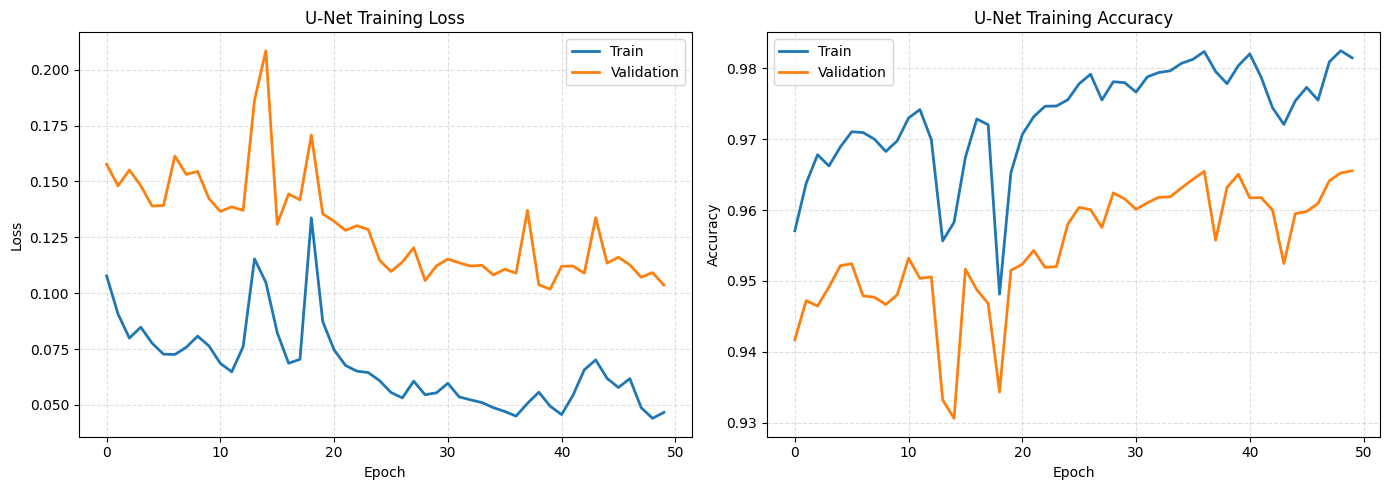

In [ ]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# Plot Training History
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ================= Loss =================
axes[0].plot(history["loss"], label="Train", linewidth=2)
axes[0].plot(history["val_loss"], label="Validation", linewidth=2)

axes[0].set_title("U-Net Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend()

# ================= Accuracy =================
axes[1].plot(history["accuracy"], label="Train", linewidth=2)
axes[1].plot(history["val_accuracy"], label="Validation", linewidth=2)

axes[1].set_title("U-Net Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "training_curves_alv_lulc_unet.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import numpy as np
import tensorflow as tf

def per_class_iou(predictions, targets, n_classes=7):
    """
    Compute IoU for each ALV LULC class.

    Classes:
    0 = Background
    1 = Built-up
    2 = Cropland
    3 = Road
    4 = Water
    5 = Forest
    6 = Bare soil

    Parameters
    ----------
    predictions : Tensor or ndarray
        Model output of shape (B, H, W, 7) after softmax.

    targets : Tensor or ndarray
        Ground-truth labels of shape (B, H, W).

    Returns
    -------
    ious : list
        IoU for each class.
    """

    # Tensor -> NumPy
    if tf.is_tensor(predictions):
        predictions = predictions.numpy()

    if tf.is_tensor(targets):
        targets = targets.numpy()

    # Convert softmax probabilities to class labels
    preds = np.argmax(predictions, axis=-1)

    ious = []

    for c in range(n_classes):

        pred_mask = (preds == c)
        true_mask = (targets == c)

        intersection = np.logical_and(pred_mask, true_mask).sum()
        union = np.logical_or(pred_mask, true_mask).sum()

        if union == 0:
            iou = np.nan
        else:
            iou = intersection / (union + 1e-7)

        ious.append(iou)

    return ious


def mean_iou(predictions, targets, n_classes=7):
    """
    Compute mean IoU while ignoring absent classes.
    """
    ious = per_class_iou(predictions, targets, n_classes)
    return np.nanmean(ious)

In [ ]:
probs = model.predict(X_val)

ious = per_class_iou(probs, Y_val, n_classes=N_CLASSES)

print("Per-class IoU")
print("-" * 35)

for name, iou in zip(CLASS_NAMES, ious):
    if np.isnan(iou):
        print(f"{name:12s}: N/A")
    else:
        print(f"{name:12s}: {iou:.4f}")

print("-" * 35)
print(f"Mean IoU: {np.nanmean(ious):.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Per-class IoU
-----------------------------------
Background  : 0.9595
Built-up    : 0.7529
Cropland    : 0.7475
Road        : 0.5723
Water       : 0.8818
Forest      : 0.8431
Bare soil   : 0.5769
-----------------------------------
Mean IoU: 0.7620


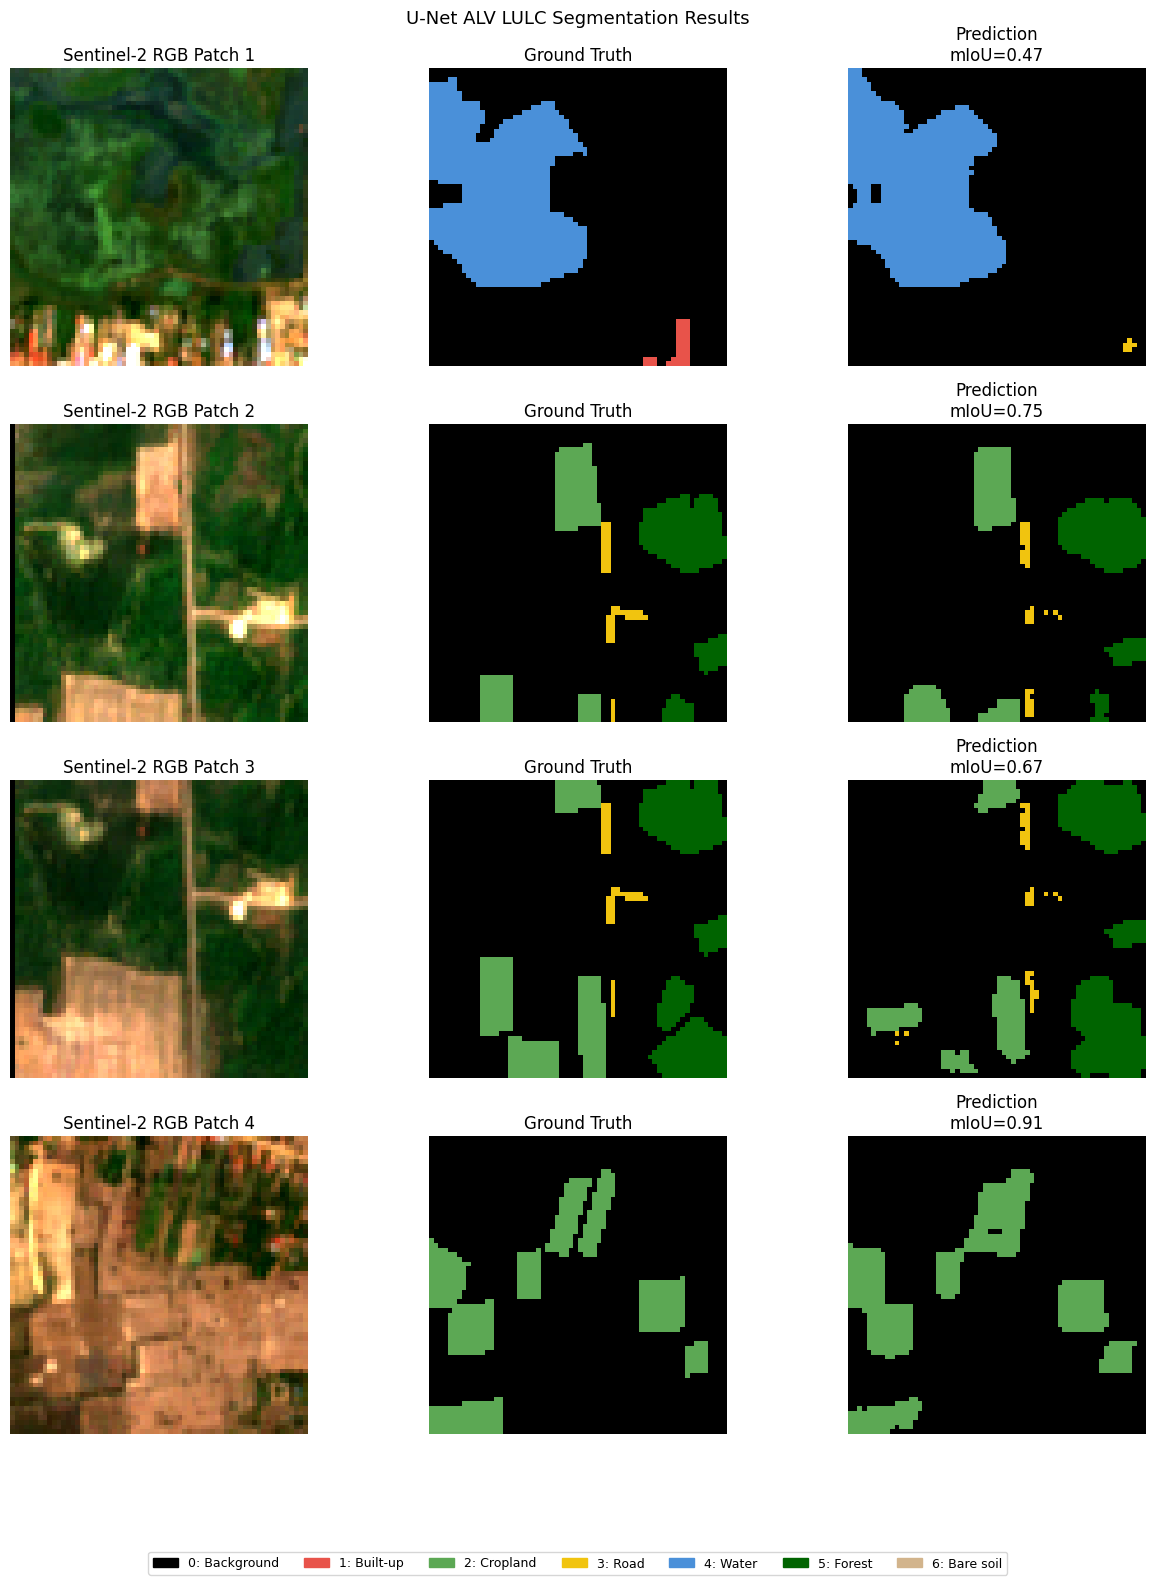

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import ListedColormap

imgs_batch, lbls_batch = next(iter(val_ds))

# Model output: softmax probabilities (B,H,W,7)
probs_batch = model(imgs_batch, training=False).numpy()

# Convert probabilities to class map
preds_batch = np.argmax(probs_batch, axis=-1)   # (B,H,W)

cmap = ListedColormap(CLASS_COLORS)

n_show = min(4, imgs_batch.shape[0])

fig, axes = plt.subplots(n_show, 3, figsize=(13, 4 * n_show))

if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):

    # Sentinel-2 RGB: B4, B3, B2
    rgb = imgs_batch[i].numpy()[:, :, [2, 1, 0]]

    valid = rgb[rgb > 0]
    if valid.size > 0:
        low = np.percentile(valid, 2)
        high = np.percentile(valid, 98)

        if high > low:
            rgb = np.clip((rgb - low) / (high - low), 0, 1)

    gt = lbls_batch[i].numpy()
    pred = preds_batch[i]

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"Sentinel-2 RGB Patch {i+1}")

    axes[i, 1].imshow(gt, cmap=cmap, vmin=0, vmax=N_CLASSES-1)
    axes[i, 1].set_title("Ground Truth")

    axes[i, 2].imshow(pred, cmap=cmap, vmin=0, vmax=N_CLASSES-1)

    patch_iou = per_class_iou(
        probs_batch[i:i+1],
        gt[np.newaxis, :, :],
        n_classes=N_CLASSES
    )

    miou_patch = np.nanmean(patch_iou)

    axes[i, 2].set_title(f"Prediction\nmIoU={miou_patch:.2f}")

for ax in axes.ravel():
    ax.axis("off")

legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[i], label=f"{i}: {CLASS_NAMES[i]}")
    for i in range(N_CLASSES)
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=N_CLASSES,
    fontsize=9
)

plt.suptitle("U-Net ALV LULC Segmentation Results", fontsize=13)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("unet_alv_lulc_predictions.png", dpi=300)
plt.show()

Prediction map: (255, 303)
Predicted classes: [0 1 2 3 4 5 6]


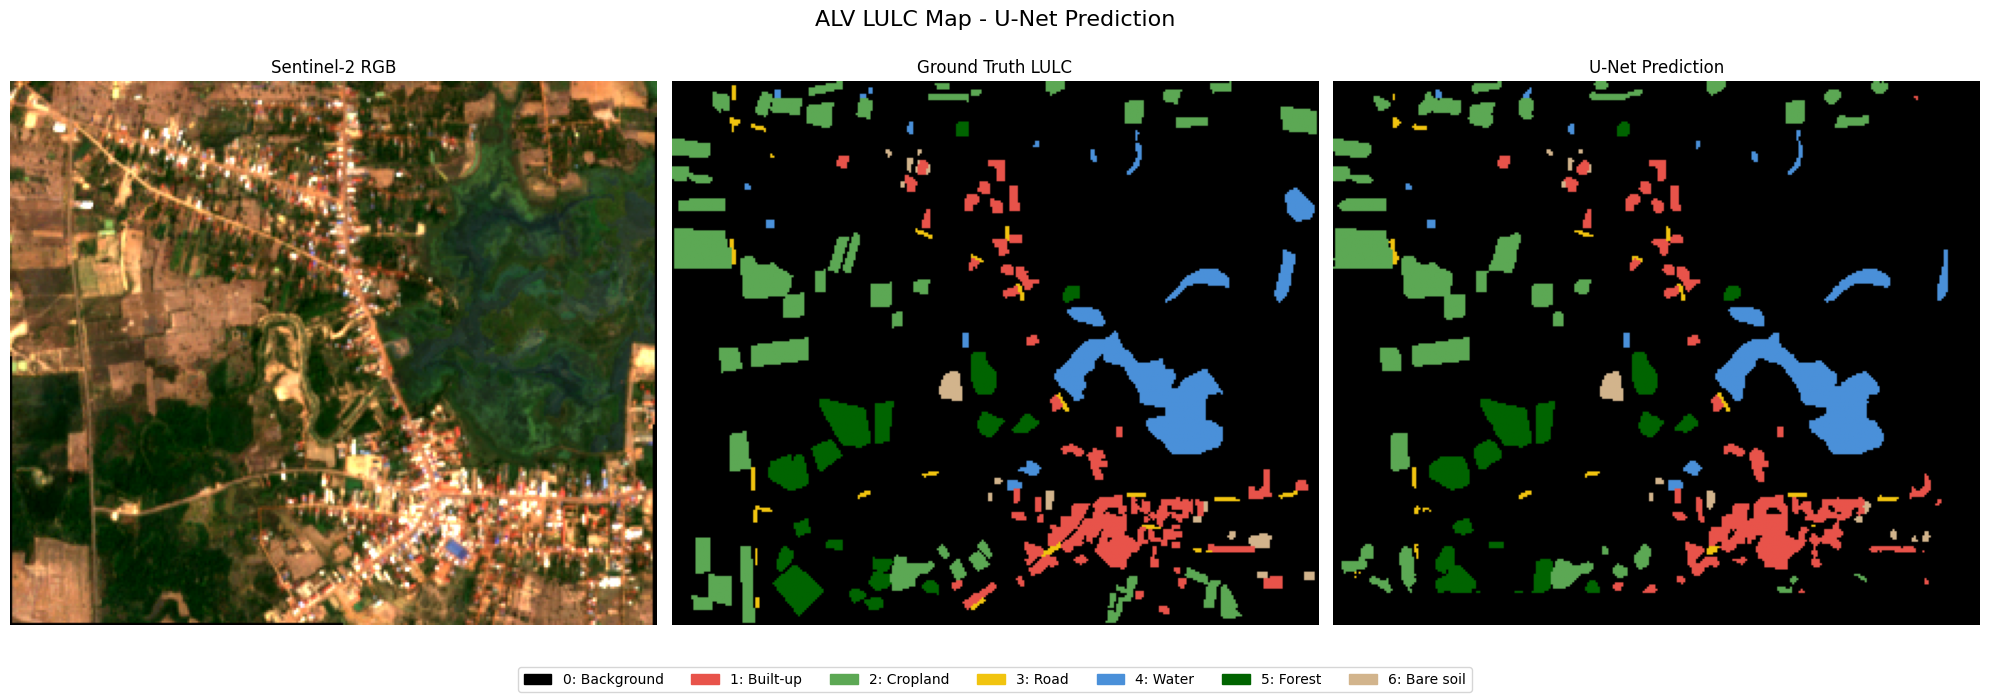

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# ---------------------------------------------------
# Class metadata after remap
# ---------------------------------------------------
N_CLASSES = 7

CLASS_NAMES = [
    "Background",
    "Built-up",
    "Cropland",
    "Road",
    "Water",
    "Forest",
    "Bare soil"
]

CLASS_COLORS = [
    "#000000",
    "#E8534A",
    "#5CA854",
    "#F1C40F",
    "#4A90D9",
    "#006400",
    "#D2B48C"
]

cmap = ListedColormap(CLASS_COLORS)

# ---------------------------------------------------
# Full-scene prediction with sliding window
# ---------------------------------------------------
PATCH_SIZE = 64
STRIDE = 16

def predict_full_scene(model, scene_img, patch_size=64, stride=16, n_classes=7):
    h, w, c = scene_img.shape

    prob_sum = np.zeros((h, w, n_classes), dtype=np.float32)
    count_sum = np.zeros((h, w, 1), dtype=np.float32)

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):

            patch = scene_img[y:y+patch_size, x:x+patch_size, :]
            patch = np.expand_dims(patch, axis=0)

            prob = model.predict(patch, verbose=0)[0]

            prob_sum[y:y+patch_size, x:x+patch_size, :] += prob
            count_sum[y:y+patch_size, x:x+patch_size, :] += 1

    prob_avg = prob_sum / np.maximum(count_sum, 1)
    pred_map = np.argmax(prob_avg, axis=-1)

    return pred_map


pred_map = predict_full_scene(
    model,
    scene_img,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    n_classes=N_CLASSES
)

print("Prediction map:", pred_map.shape)
print("Predicted classes:", np.unique(pred_map))


# ---------------------------------------------------
# Prepare Sentinel-2 RGB
# ---------------------------------------------------
rgb = scene_img[:, :, [2, 1, 0]]

valid = rgb[rgb > 0]
if valid.size > 0:
    low = np.percentile(valid, 2)
    high = np.percentile(valid, 98)

    if high > low:
        rgb = np.clip((rgb - low) / (high - low), 0, 1)


# ---------------------------------------------------
# Plot full ALV LULC map
# ---------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(20, 7))

ax[0].imshow(rgb)
ax[0].set_title("Sentinel-2 RGB")
ax[0].axis("off")

ax[1].imshow(scene_label, cmap=cmap, vmin=0, vmax=N_CLASSES-1)
ax[1].set_title("Ground Truth LULC")
ax[1].axis("off")

ax[2].imshow(pred_map, cmap=cmap, vmin=0, vmax=N_CLASSES-1)
ax[2].set_title("U-Net Prediction")
ax[2].axis("off")

legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[i], label=f"{i}: {CLASS_NAMES[i]}")
    for i in range(N_CLASSES)
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=N_CLASSES,
    fontsize=10
)

plt.suptitle("ALV LULC Map - U-Net Prediction", fontsize=16)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("alv_lulc_full_map_unet.png", dpi=300, bbox_inches="tight")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


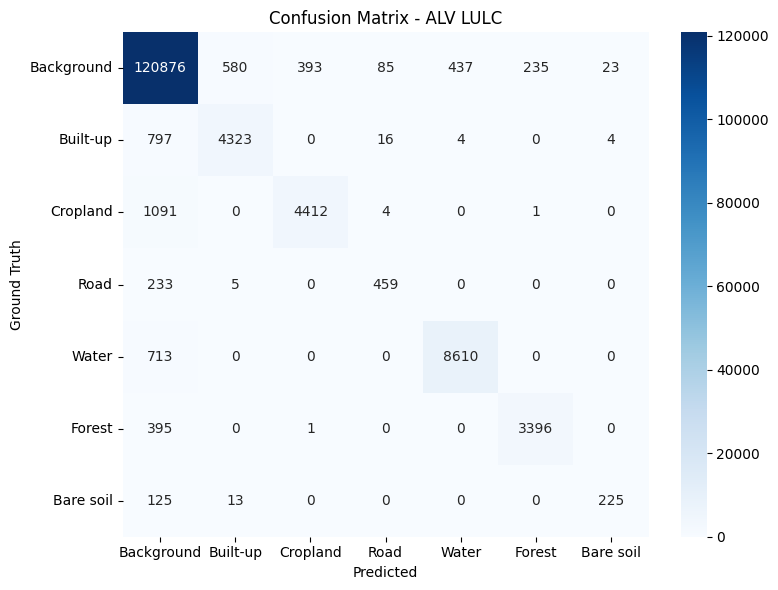

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get true validation labels from Y_val (already flattened or can be flattened later)
true_val = Y_val.flatten()

# Generate predictions for the entire validation set
pred_probs_val = model.predict(X_val)
pred_val = np.argmax(pred_probs_val, axis=-1).flatten()

cm = confusion_matrix(
    true_val,
    pred_val,
    labels=list(range(N_CLASSES))
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix - ALV LULC")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_val,
        pred_val,
        target_names=CLASS_NAMES,
        digits=3
    )
)

              precision    recall  f1-score   support

  Background      0.973     0.986     0.979    122629
    Built-up      0.878     0.840     0.859      5144
    Cropland      0.918     0.801     0.856      5508
        Road      0.814     0.659     0.728       697
       Water      0.951     0.924     0.937      9323
      Forest      0.935     0.896     0.915      3792
   Bare soil      0.893     0.620     0.732       363

    accuracy                          0.965    147456
   macro avg      0.909     0.818     0.858    147456
weighted avg      0.964     0.965     0.964    147456

